In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
play_by_play_clean = pd.read_csv(
    "C:/Users/caro_/OneDrive/Escritorio/Proyecto Final DAPT10/play_by_play_clean.csv"
    )

In [47]:
game_clean = pd.read_csv(
"C:/Users/caro_/OneDrive/Escritorio/Proyecto Final DAPT10/game_clean.csv"
)

In [48]:
game_info_clean = pd.read_csv(
"C:/Users/caro_/OneDrive/Escritorio/Proyecto Final DAPT10/game_info_clean.csv",
)

In [49]:
other_stats_cleaned_final = pd.read_csv(
"C:/Users/caro_/OneDrive/Escritorio\Proyecto Final DAPT10/other_stats_cleaned_final.csv"
)

In [42]:
draft_history_clean = pd.read_csv(
"C:/Users/caro_/OneDrive\Escritorio/Proyecto Final DAPT10/draft_history_clean.csv"
)

In [35]:
common_player_info_clean = pd.read_csv(
"C:/Users/caro_/OneDrive/Escritorio/Proyecto Final DAPT10/common_player_info_clean.csv",
)

In [9]:
draft_combine_stats_clean = pd.read_csv(
    "C:/Users/caro_/OneDrive/Escritorio/Proyecto Final DAPT10/draft_combine_stats_clean.csv"
)

In [24]:
player_clean = pd.read_csv(
    "C:/Users/caro_/OneDrive/Escritorio/Proyecto Final DAPT10/player_clean.csv"
)

In [12]:
# creacion de dataset con performance de cada jugador
pbp = play_by_play_clean.copy()

# Convertir season desde game_clean
games_season = game_clean[["game_id", "season_id"]]

pbp = pbp.merge(games_season, on="game_id", how="inner")

In [14]:
# METRICAS BÁSICAS POR JUGADOR
#  Filtrar eventos de puntos (eventmsgtype 1 = tiro convertido)
points = pbp[pbp["eventmsgtype"] == 1]

player_points = (
    points.groupby(["player1_id", "season_id"])
    .size()
    .reset_index(name="fgm")
)

# Asistencias (eventmsgtype 1 pero con player2_id no nulo)
assists = (
    points[pbp["player2_id"].notna()]
    .groupby(["player2_id", "season_id"])
    .size()
    .reset_index(name="ast")
    .rename(columns={"player2_id": "player1_id"})
)

# Robos (eventmsgtype 5)
steals = (
    pbp[pbp["eventmsgtype"] == 5]
    .groupby(["player1_id", "season_id"])
    .size()
    .reset_index(name="stl")
)

# Rebotes (eventmsgtype 4)
rebounds = (
    pbp[pbp["eventmsgtype"] == 4]
    .groupby(["player1_id", "season_id"])
    .size()
    .reset_index(name="reb")
)

# Unir todo
performance = player_points.merge(assists, on=["player1_id","season_id"], how="left")
performance = performance.merge(steals, on=["player1_id","season_id"], how="left")
performance = performance.merge(rebounds, on=["player1_id","season_id"], how="left")

performance = performance.fillna(0)

C:\Users\caro_\AppData\Local\Temp\ipykernel_18708\3493211221.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  points[pbp["player2_id"].notna()]


In [16]:
# Normalizar por temporada (z-score)
metrics = ["fgm", "ast", "stl", "reb"]

for metric in metrics:
    performance[f"{metric}_z"] = (
        performance.groupby("season_id")[metric]
        .transform(lambda x: (x - x.mean()) / x.std())
    )

In [17]:
# Crear player performance index
performance["PPI"] = (
    0.40 * performance["fgm_z"] +
    0.25 * performance["ast_z"] +
    0.20 * performance["reb_z"] +
    0.15 * performance["stl_z"]
)

In [19]:
# Top 20 jugadores 2023
top20_2023 = (
    performance[performance["season_id"] == 2023]
    .sort_values("PPI", ascending=False)
    .head(20)
)

top20_ids = top20_2023["player1_id"].unique()

In [21]:
# EVOLUCIÓN HISTÓRICA DE LOS TOP 20
top20_history = performance[
    performance["player1_id"].isin(top20_ids)
]

# Ordenar
top20_history = top20_history.sort_values(["player1_id","season_id"])

In [ ]:
# Calcular pendiente (regresión lineal simple)
from sklearn.linear_model import LinearRegression

def calculate_slope(df):
    X = df["season_id"].values.reshape(-1,1)
    y = df["PPI"].values
    if len(df) > 1:
        model = LinearRegression().fit(X,y)
        return model.coef_[0]
    else:
        return np.nan

slopes = (
    top20_history.groupby("player1_id")
    .apply(calculate_slope)
    .reset_index(names="PPI_slope")
)

C:\Users\caro_\AppData\Local\Temp\ipykernel_18708\1034206224.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_slope)


In [26]:
#DETECTAR DECLIVE
#Declive si:
#Pendiente negativa
#Últimos 3 años caída > 15%
decline_list = []

for player in top20_ids:
    df = top20_history[top20_history["player1_id"] == player].sort_values("season_id")
    
    if len(df) >= 4:
        last3 = df.tail(3)["PPI"].mean()
        prev3 = df.iloc[-6:-3]["PPI"].mean() if len(df) >= 6 else df.iloc[:-3]["PPI"].mean()
        
        change = (last3 - prev3) / abs(prev3)
        
        if change <= -0.15:
            decline_list.append(player)

decline_players = pd.DataFrame(decline_list, columns=["player1_id"])

In [27]:
# CALCULAR ROI
# salario proxy 
SALARY = 8_000_000

performance["Value"] = performance["PPI"] * SALARY
performance["ROI"] = (performance["Value"] - SALARY) / SALARY

In [29]:
# ROI promedio últimos 3 años
roi_recent = (
    performance[performance["season_id"] >= 2021]
    .groupby("player1_id")["ROI"]
    .mean()
    .reset_index()
)

In [ ]:
# DRAFT VS PERFORMANCE
# unimos frafts
draft_perf = performance.merge(
    draft_history_clean[["person_id","overall_pick"]],
    left_on="player1_id",
    right_on="person_id",
    how="left"
)

In [31]:
# Correlacion
draft_perf["overall_pick"] = pd.to_numeric(draft_perf["overall_pick"], errors="coerce")

corr = draft_perf[["overall_pick","PPI"]].corr()
print(corr)

              overall_pick       PPI
overall_pick      1.000000 -0.321253
PPI              -0.321253  1.000000


In [32]:
# CLUSTERING DE TRAYECTORIAS
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

career_stats = (
    performance.groupby("player1_id")
    .agg({
        "PPI":"mean",
        "ROI":"mean"
    })
    .reset_index()
)

scaler = StandardScaler()
X = scaler.fit_transform(career_stats[["PPI","ROI"]])

kmeans = KMeans(n_clusters=4, random_state=42)
career_stats["cluster"] = kmeans.fit_predict(X)

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

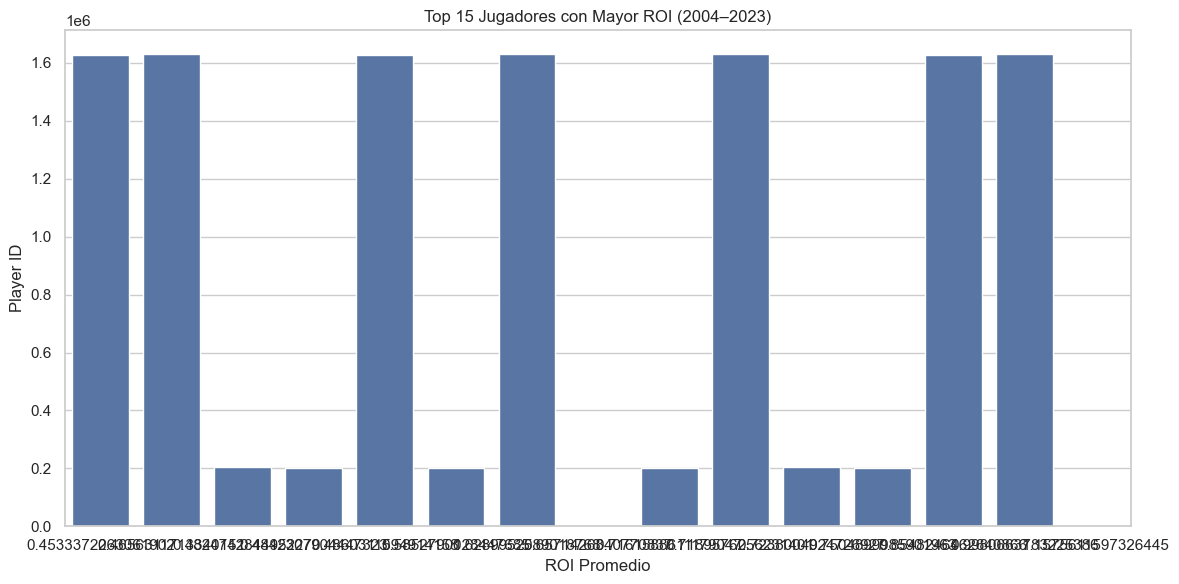

In [38]:
roi_career = (
    performance.groupby("player1_id")["ROI"]
    .mean()
    .reset_index()
)

top_roi = roi_career.sort_values("ROI", ascending=False).head(15)

plt.figure()

sns.barplot(
    data=top_roi,
    x="ROI",
    y="player1_id"
)

plt.title("Top 15 Jugadores con Mayor ROI (2004–2023)")
plt.xlabel("ROI Promedio")
plt.ylabel("Player ID")
plt.tight_layout()
plt.show()

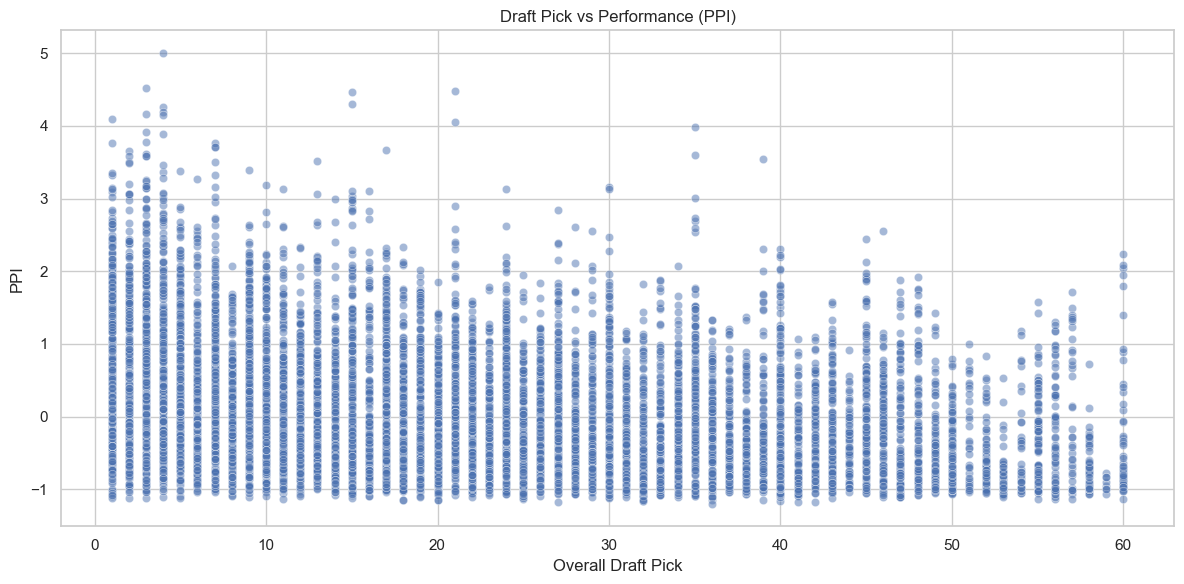

In [39]:
plt.figure()

sns.scatterplot(
    data=draft_perf,
    x="overall_pick",
    y="PPI",
    alpha=0.5
)

plt.title("Draft Pick vs Performance (PPI)")
plt.xlabel("Overall Draft Pick")
plt.ylabel("PPI")
plt.tight_layout()
plt.show()

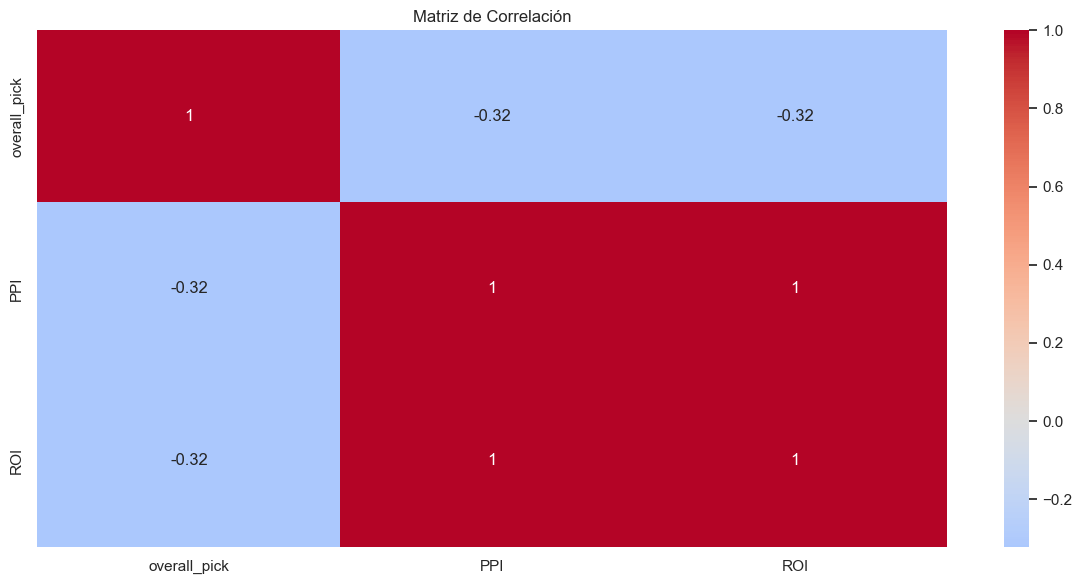

In [40]:
corr_matrix = draft_perf[[
    "overall_pick",
    "PPI",
    "ROI"
]].corr()

plt.figure()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()

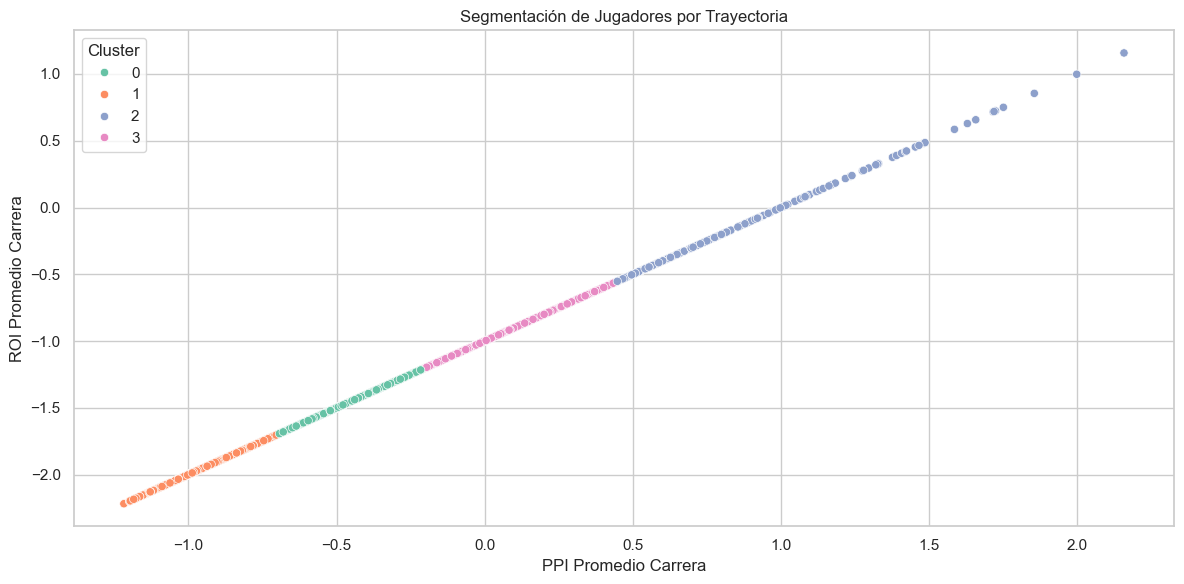

In [41]:
plt.figure()

sns.scatterplot(
    data=career_stats,
    x="PPI",
    y="ROI",
    hue="cluster",
    palette="Set2"
)

plt.title("Segmentación de Jugadores por Trayectoria")
plt.xlabel("PPI Promedio Carrera")
plt.ylabel("ROI Promedio Carrera")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.animation import FuncAnimation

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [50]:
# Años activos reales
career_length = (
    common_player_info_clean
    .assign(
        from_year=lambda x: pd.to_numeric(x["from_year"], errors="coerce"),
        to_year=lambda x: pd.to_numeric(x["to_year"], errors="coerce")
    )
)

career_length["career_years"] = (
    career_length["to_year"] - career_length["from_year"]
)

career_length["rentable"] = np.where(
    career_length["career_years"] >= 5,
    1, 0
)

career_length[["player_id","career_years","rentable"]].head()

,player_id,career_years,rentable
0,949,11.0,1
1,203518,2.0,0
2,1630173,3.0,0
3,101165,3.0,0
4,203112,6.0,1


In [52]:
# Crear dataset por equipo (home + away unificado)

home_stats = game_clean[[
    "game_id","season_id","team_id_home",
    "fgm_home","fga_home","fg_pct_home",
    "fg3_pct_home","ft_pct_home",
    "pts_home"
]].copy()

home_stats.columns = [
    "game_id","season_id","team_id",
    "fgm","fga","fg_pct",
    "fg3_pct","ft_pct",
    "pts"
]

volume_efficiency = (
    home_stats
    .groupby(["team_id","season_id"])
    .mean()
    .reset_index()
)

volume_efficiency.head()

,team_id,season_id,game_id,fgm,fga,fg_pct,fg3_pct,ft_pct,pts
0,45,12007,10700067.0,26.0,67.0,0.388,0.419,0.692,92.0
1,94,12010,11000001.0,38.0,79.0,0.481,0.348,0.784,113.0
2,94,12012,11200010.0,26.0,83.0,0.313,0.300,0.778,75.0
3,94,12015,11500016.0,37.0,83.0,0.446,0.346,0.500,91.0
4,12303,12006,10600016.0,39.0,81.0,0.481,0.304,0.708,102.0


In [53]:
# Métricas físicas
physical_metrics = draft_combine_stats_clean[[
    "player_id",
    "height_wo_shoes",
    "weight",
    "wingspan",
    "body_fat_pct"
]]

# Rebotes y robos ya calculados en performance
physical_perf = performance[[
    "player1_id",
    "season_id",
    "reb",
    "stl"
]].copy()

physical_perf.head()

,player1_id,season_id,reb,stl
0,15,22003,37.0,15.0
1,15,22004,68.0,28.0
2,15,22005,17.0,9.0
3,15,22006,8.0,4.0
4,15,22007,9.0,5.0


In [55]:
# Turnovers eventmsgtype = 5 (ajusta si es otro código)
turnovers = (
    pbp[pbp["eventmsgtype"] == 5]
    .groupby(["player1_id","season_id"])
    .size()
    .reset_index(name="tov")
)

performance = performance.merge(
    turnovers,
    on=["player1_id","season_id"],
    how="left"
).fillna(0)

In [56]:
performance["control_ratio"] = (
    performance["ast"] /
    (performance["ast"] + performance["tov"] + 1)
)

In [59]:
games_played = (
    pbp.groupby(["player1_id","season_id"])["game_id"]
    .nunique()
    .reset_index(name="games_played")
)

performance = performance.merge(
    games_played,
    on=["player1_id","season_id"],
    how="left"
)

In [60]:
game_dates = game_info_clean[["game_id","game_date"]]

pbp_dates = pbp.merge(game_dates, on="game_id")

pbp_dates["game_date"] = pd.to_datetime(pbp_dates["game_date"])

inactivity = (
    pbp_dates
    .sort_values(["player1_id","game_date"])
)

inactivity["days_off"] = (
    inactivity.groupby("player1_id")["game_date"]
    .diff()
    .dt.days
)

inactivity_metric = (
    inactivity.groupby(["player1_id","season_id"])["days_off"]
    .mean()
    .reset_index()
)

In [61]:
performance = performance.sort_values(["player1_id","season_id"])

performance["ast_change"] = (
    performance.groupby("player1_id")["ast"]
    .pct_change()
)

performance["alert_decline"] = np.where(
    performance["ast_change"] <= -0.20,
    1, 0
)

In [62]:
model_data = performance.merge(
    career_length[["player_id","rentable"]],
    left_on="player1_id",
    right_on="player_id",
    how="left"
)

rentables = model_data[model_data["rentable"] == 1]
no_rentables = model_data[model_data["rentable"] == 0]

In [63]:
thresholds = pd.DataFrame({
    "metric": ["ast","reb","fgm","control_ratio"],
    "rentable_mean": [
        rentables["ast"].mean(),
        rentables["reb"].mean(),
        rentables["fgm"].mean(),
        rentables["control_ratio"].mean()
    ],
    "no_rentable_mean": [
        no_rentables["ast"].mean(),
        no_rentables["reb"].mean(),
        no_rentables["fgm"].mean(),
        no_rentables["control_ratio"].mean()
    ]
})

thresholds

,metric,rentable_mean,no_rentable_mean
0,ast,69.235047,25.503143
1,reb,131.564828,51.562706
2,fgm,117.559277,43.773421
3,control_ratio,0.528444,0.455218


In [66]:
print("Performance shape:", performance.shape)
print("Seasons disponibles:", sorted(performance["season_id"].dropna().unique())[:5], "...")

print("Model data shape:", model_data.shape)
print("Rentables:", model_data["rentable"].value_counts())

Performance shape: (17389, 18)
Seasons disponibles: [np.int64(12013), np.int64(12014), np.int64(12015), np.int64(12016), np.int64(12017)] ...
Model data shape: (17389, 20)
Rentables: rentable
1.0    11168
0.0     3341
Name: count, dtype: int64


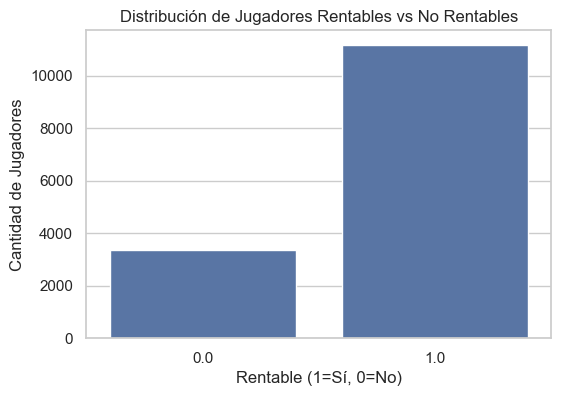

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(6,4))

sns.countplot(data=model_data, x="rentable")

plt.title("Distribución de Jugadores Rentables vs No Rentables")
plt.xlabel("Rentable (1=Sí, 0=No)")
plt.ylabel("Cantidad de Jugadores")

plt.show()

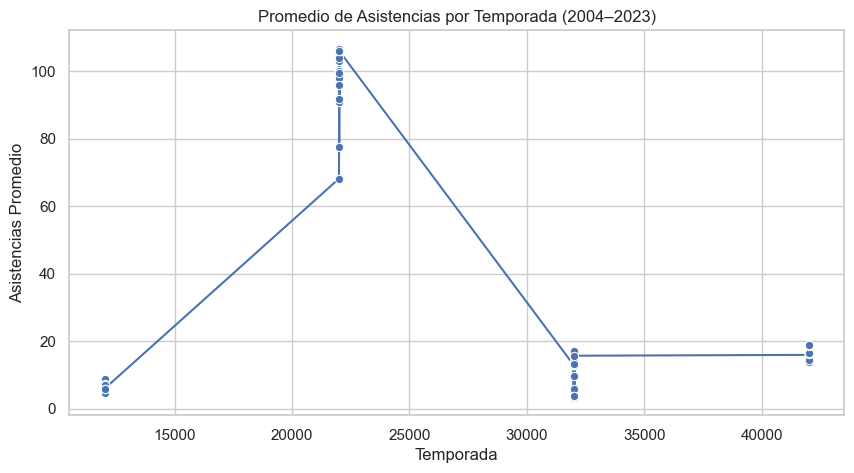

In [68]:
avg_ast = (
    performance.groupby("season_id")["ast"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(data=avg_ast, x="season_id", y="ast", marker="o")

plt.title("Promedio de Asistencias por Temporada (2004–2023)")
plt.xlabel("Temporada")
plt.ylabel("Asistencias Promedio")

plt.show()

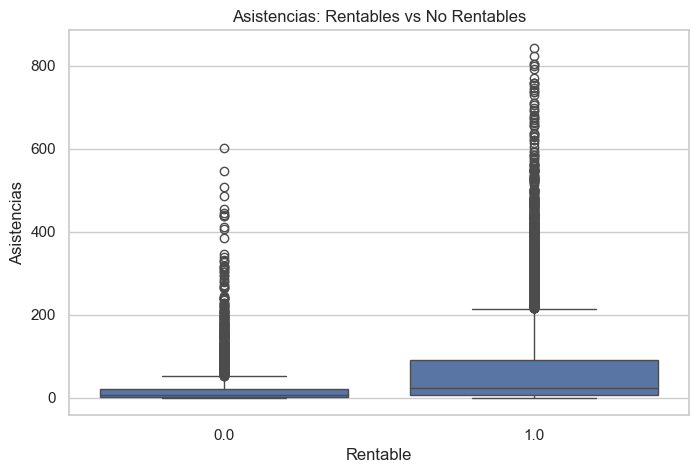

In [69]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=model_data,
    x="rentable",
    y="ast"
)

plt.title("Asistencias: Rentables vs No Rentables")
plt.xlabel("Rentable")
plt.ylabel("Asistencias")

plt.show()

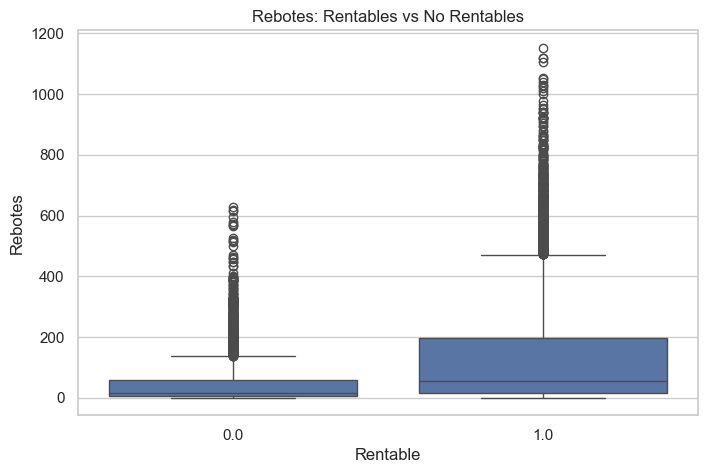

In [70]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=model_data,
    x="rentable",
    y="reb"
)

plt.title("Rebotes: Rentables vs No Rentables")
plt.xlabel("Rentable")
plt.ylabel("Rebotes")

plt.show()

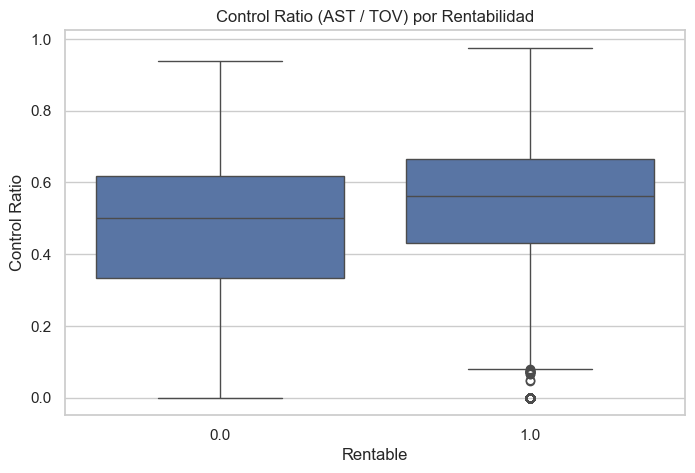

In [71]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=model_data,
    x="rentable",
    y="control_ratio"
)

plt.title("Control Ratio (AST / TOV) por Rentabilidad")
plt.xlabel("Rentable")
plt.ylabel("Control Ratio")

plt.show()

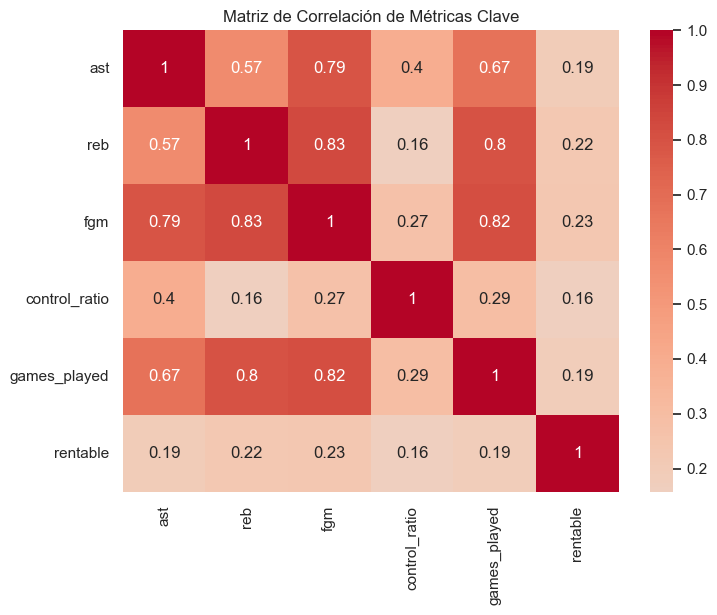

In [72]:
corr_vars = model_data[[
    "ast",
    "reb",
    "fgm",
    "control_ratio",
    "games_played",
    "rentable"
]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr_vars, annot=True, cmap="coolwarm", center=0)

plt.title("Matriz de Correlación de Métricas Clave")

plt.show()

In [102]:
(play_by_play_clean.columns)

Index(['game_id', 'eventnum', 'eventmsgtype', 'eventmsgactiontype', 'period',
       'wctimestring', 'pctimestring', 'score', 'scoremargin', 'person1type',
       'player1_id', 'player1_name', 'player1_team_id', 'player1_team_city',
       'player1_team_nickname', 'player1_team_abbreviation', 'person2type',
       'player2_id', 'player2_name', 'player2_team_id', 'player2_team_city',
       'player2_team_nickname', 'player2_team_abbreviation', 'person3type',
       'player3_id', 'player3_name', 'player3_team_id', 'player3_team_city',
       'player3_team_nickname', 'player3_team_abbreviation',
       'video_available_flag', 'event_description'],
      dtype='object')

In [3]:
import pandas as pd
import numpy as np

# ============================================================
# PASO 1: Inspección previa a la limpieza
# ============================================================

print("=" * 60)
print("📊 INSPECCIÓN PREVIA - play_by_play_clean")
print("=" * 60)

# Columnas de team_id a revisar
team_id_cols = [
    'player1_team_id',
    'player2_team_id',
    'player3_team_id'
]

for col in team_id_cols:
    if col in play_by_play_clean.columns:
        print(f"\n🔎 Columna: {col}")
        print(f"   Total registros     : {len(play_by_play_clean)}")
        print(f"   Valores nulos       : {play_by_play_clean[col].isna().sum()}")
        print(f"   Valores únicos      : {play_by_play_clean[col].nunique()}")

        # Convertir a string para analizar prefijo
        sample_ids = (
            play_by_play_clean[col]
            .dropna()
            .astype(str)
            .unique()
        )

        # Identificar prefijos
        prefixes = pd.Series(sample_ids).str[:3].value_counts()
        print(f"\n   Top prefijos encontrados:")
        print(prefixes.to_string())


📊 INSPECCIÓN PREVIA - play_by_play_clean

🔎 Columna: player1_team_id
   Total registros     : 13592899
   Valores nulos       : 1215858
   Valores únicos      : 51

   Top prefijos encontrados:
161    32
123    10
150     5
93.     1
41.     1
94.     1
500     1

🔎 Columna: player2_team_id
   Total registros     : 13592899
   Valores nulos       : 9660454
   Valores únicos      : 51

   Top prefijos encontrados:
161    32
123    10
150     5
93.     1
41.     1
94.     1
500     1

🔎 Columna: player3_team_id
   Total registros     : 13592899
   Valores nulos       : 13246931
   Valores únicos      : 49

   Top prefijos encontrados:
161    32
123     8
150     5
93.     1
41.     1
94.     1
500     1


In [5]:
# PASO 2: Función de validación de ID NBA
# ============================================================

def is_nba_team_id(team_id) -> bool:
    """
    Valida si un team_id pertenece a la NBA.
    Los IDs NBA reales comienzan con '161' (ej: 1610612761).

    Parameters:
        team_id: valor a evaluar (int, float o str)

    Returns:
        bool: True si es ID NBA válido
    """
    if pd.isna(team_id):
        return True  # Nulos se conservan (pueden ser eventos sin equipo)

    team_id_str = str(int(float(team_id))) if str(team_id) != 'nan' else ''

    return team_id_str.startswith('161')


# ── Test rápido ──────────────────────────────────────────────
test_ids = [1610612761, 1230000001, None, 1610612747, 9999999, float('nan')]
print("🧪 Test de validación:")
for tid in test_ids:
    print(f"   ID: {str(tid):<15} → NBA válido: {is_nba_team_id(tid)}")




🧪 Test de validación:
   ID: 1610612761      → NBA válido: True
   ID: 1230000001      → NBA válido: False
   ID: None            → NBA válido: True
   ID: 1610612747      → NBA válido: True
   ID: 9999999         → NBA válido: False
   ID: nan             → NBA válido: True


In [6]:
# PASO 3: Diagnóstico - cuántos registros serán afectados
# ============================================================

print("\n" + "=" * 60)
print("📋 DIAGNÓSTICO DE REGISTROS A ELIMINAR")
print("=" * 60)

# Registros donde player2_team_id NO es NBA
# (El caso mencionado: empieza con 1.23 → 123...)
mask_invalid_p1 = (
    play_by_play_clean['player1_team_id']
    .dropna()
    .astype(str)
    .apply(lambda x: not str(int(float(x))).startswith('161'))
)

mask_invalid_p2 = (
    play_by_play_clean['player2_team_id']
    .dropna()
    .astype(str)
    .apply(lambda x: not str(int(float(x))).startswith('161'))
)

mask_invalid_p3 = (
    play_by_play_clean['player3_team_id']
    .dropna()
    .astype(str)
    .apply(lambda x: not str(int(float(x))).startswith('161'))
)

print(f"\n   player1_team_id inválidos: {mask_invalid_p1.sum():,}")
print(f"   player2_team_id inválidos: {mask_invalid_p2.sum():,}")
print(f"   player3_team_id inválidos: {mask_invalid_p3.sum():,}")

# Mostrar ejemplos de IDs inválidos
print("\n   Ejemplos de IDs NO-NBA encontrados:")
for col in team_id_cols:
    invalid_sample = (
        play_by_play_clean[col]
        .dropna()
        .astype(str)
        .loc[lambda x: ~x.apply(
            lambda v: str(int(float(v))).startswith('161')
        )]
        .unique()[:5]
    )
    if len(invalid_sample) > 0:
        print(f"   {col}: {invalid_sample}")



📋 DIAGNÓSTICO DE REGISTROS A ELIMINAR

   player1_team_id inválidos: 9,067
   player2_team_id inválidos: 3,316
   player3_team_id inválidos: 153

   Ejemplos de IDs NO-NBA encontrados:
   player1_team_id: ['12321.0' '12324.0' '12308.0' '93.0' '41.0']
   player2_team_id: ['12321.0' '12324.0' '12308.0' '93.0' '41.0']
   player3_team_id: ['12321.0' '12308.0' '93.0' '41.0' '12323.0']


In [7]:
# PASO 4: Limpieza principal
# ============================================================

print("\n" + "=" * 60)
print("🧹 APLICANDO LIMPIEZA")
print("=" * 60)

df_before = len(play_by_play_clean)

# ── 4.1 Función vectorizada de validación ───────────────────
def validate_nba_id_series(series: pd.Series) -> pd.Series:
    """
    Retorna máscara booleana:
    True  → ID válido NBA o nulo (conservar)
    False → ID de otra liga (eliminar)
    """
    def check(val):
        if pd.isna(val):
            return True  # Nulo = conservar
        try:
            return str(int(float(val))).startswith('161')
        except (ValueError, OverflowError):
            return False  # Valor extraño = descartar

    return series.apply(check)


# ── 4.2 Construir máscara combinada ─────────────────────────
# Solo filtramos filas donde el ID está presente Y es inválido
# Los nulos se CONSERVAN (muchos eventos no tienen player2/player3)

mask_p1_ok = validate_nba_id_series(play_by_play_clean['player1_team_id'])
mask_p2_ok = validate_nba_id_series(play_by_play_clean['player2_team_id'])
mask_p3_ok = validate_nba_id_series(play_by_play_clean['player3_team_id'])

# Fila válida = todos los IDs presentes son NBA
combined_mask = mask_p1_ok & mask_p2_ok & mask_p3_ok

# ── 4.3 Aplicar filtro ──────────────────────────────────────
play_by_play_clean = play_by_play_clean[combined_mask].copy()

df_after = len(play_by_play_clean)

print(f"\n   ✅ Registros antes : {df_before:>10,}")
print(f"   ✅ Registros después: {df_after:>10,}")
print(f"   🗑️  Eliminados      : {df_before - df_after:>10,}")
print(f"   📊 % conservado    : {(df_after/df_before)*100:.2f}%")



🧹 APLICANDO LIMPIEZA

   ✅ Registros antes : 13,592,899
   ✅ Registros después: 13,582,349
   🗑️  Eliminados      :     10,550
   📊 % conservado    : 99.92%


In [8]:
# PASO 5: Limpieza complementaria de tipos de datos
# ============================================================

# Convertir team_ids a Int64 (soporta NaN con tipo entero)
for col in team_id_cols:
    if col in play_by_play_clean.columns:
        play_by_play_clean[col] = (
            pd.to_numeric(play_by_play_clean[col], errors='coerce')
            .astype('Int64')
        )

# Mismo tratamiento para player_ids
player_id_cols = ['player1_id', 'player2_id', 'player3_id']
for col in player_id_cols:
    if col in play_by_play_clean.columns:
        play_by_play_clean[col] = (
            pd.to_numeric(play_by_play_clean[col], errors='coerce')
            .astype('Int64')
        )

print("\n✅ Tipos de datos actualizados:")
print(
    play_by_play_clean[team_id_cols + player_id_cols]
    .dtypes
    .to_string()
)



✅ Tipos de datos actualizados:
player1_team_id    Int64
player2_team_id    Int64
player3_team_id    Int64
player1_id         Int64
player2_id         Int64
player3_id         Int64


In [9]:
# PASO 6: Validación final
# ============================================================

print("\n" + "=" * 60)
print("✅ VALIDACIÓN FINAL")
print("=" * 60)

for col in team_id_cols:
    if col in play_by_play_clean.columns:

        non_null = play_by_play_clean[col].dropna()

        if len(non_null) == 0:
            print(f"\n{col}: sin valores no-nulos")
            continue

        all_valid = non_null.astype(str).apply(
            lambda x: x.startswith('161')
        ).all()

        unique_ids = non_null.nunique()

        print(f"\n   📌 {col}")
        print(f"      IDs únicos válidos : {unique_ids}")
        print(f"      Todos son NBA      : {'✅ SÍ' if all_valid else '❌ NO'}")
        print(f"      Nulos conservados  : {play_by_play_clean[col].isna().sum():,}")

# Muestra final
print("\n📋 Muestra del dataset limpio:")
print(
    play_by_play_clean[
        ['game_id', 'player1_name', 'player1_team_id',
         'player2_name', 'player2_team_id']
    ].head(5).to_string()
)

print("\n🏁 Limpieza completada exitosamente.")



✅ VALIDACIÓN FINAL

   📌 player1_team_id
      IDs únicos válidos : 32
      Todos son NBA      : ✅ SÍ
      Nulos conservados  : 1,215,858

   📌 player2_team_id
      IDs únicos válidos : 32
      Todos son NBA      : ✅ SÍ
      Nulos conservados  : 9,654,775

   📌 player3_team_id
      IDs únicos válidos : 32
      Todos son NBA      : ✅ SÍ
      Nulos conservados  : 13,236,829

📋 Muestra del dataset limpio:
    game_id      player1_name  player1_team_id player2_name  player2_team_id
0  29600012               NaN             <NA>          NaN             <NA>
1  29600012  Shaquille O'Neal       1610612747   Joe Kleine       1610612756
2  29600012       Sam Cassell       1610612756          NaN             <NA>
3  29600012  Shaquille O'Neal       1610612747          NaN             <NA>
4  29600012   Cedric Ceballos       1610612747          NaN             <NA>

🏁 Limpieza completada exitosamente.


In [10]:
output_path = "C:/Users\caro_/Downloads/Proyecto Final DAPT10"

play_by_play_clean.to_csv(f"{output_path}play_by_play_clean.csv", index=False)

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\caro_\AppData\Local\Temp\ipykernel_3380\836073661.py:1: SyntaxWarning: invalid escape sequence '\c'
  output_path = "C:/Users\caro_/Downloads/Proyecto Final DAPT10"


In [ ]:
# ---------------------- EDA 3 ------------------------

In [14]:
#Plan del EDA — ROI de los Top 20 Jugadores (2004-2023)
#FASE 1 — Preparación y Uniones


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Cargar archivos ──────────────────────────────────────────────
player_clean       = pd.read_csv('player_clean.csv')
common_info   = pd.read_csv('common_player_info_clean.csv')
game_clean        = pd.read_csv('game_clean.csv')
draft_history = pd.read_csv('draft_history_clean.csv')

# ── Vista rápida ─────────────────────────────────────────────────
for name, df in zip(
    ['players','common_info','games','draft_history'],
    [player_clean, common_info, game_clean, draft_history]):
    print(f"\n{'='*50}")
    print(f"📄 {name}  →  {df.shape}")
    print(df.dtypes)
    print(df.head(2))



📄 players  →  (4831, 5)
player_id      int64
full_name     object
first_name    object
last_name     object
is_active       bool
dtype: object
   player_id        full_name first_name   last_name  is_active
0      76001   Alaa Abdelnaby       Alaa   Abdelnaby      False
1      76002  Zaid Abdul-Aziz       Zaid  Abdul-Aziz      False

📄 common_info  →  (1760, 34)
player_id                             int64
first_name                           object
last_name                            object
display_first_last                   object
display_last_comma_first             object
display_fi_last                      object
player_slug                          object
birthdate                            object
school                               object
country                              object
last_affiliation                     object
height                               object
weight                              float64
season_exp                          float64
jersey            

In [16]:
#FASE 2 — Definir el "ROI de Inversión"
#El ROI lo construiremos con esta lógica:

#ROI_pick = 1 / overall_pick   ← Mayor pick = mayor inversión
#ROI_score = f(pts, reb, ast)  ← Rendimiento compuesto
#ROI_final = ROI_score / ROI_pick_normalizado

# ── Filtrar drafts 2004-2018 (para tener al menos ~5 temporadas) ─
draft_filtered = draft_history[
    (draft_history['season'] >= 2004) &
    (draft_history['season'] <= 2018) &
    (draft_history['draft_type'] == 'Draft')
].copy()

# ── Normalizar pick: pick #1 = inversión máxima ──────────────────
draft_filtered['pick_value'] = 1 / draft_filtered['overall_pick']
draft_filtered['pick_value_norm'] = (
    draft_filtered['pick_value'] / draft_filtered['pick_value'].max()
)

print(draft_filtered[['player_name','season','overall_pick',
                        'pick_value_norm']].head(10))



        player_name  season  overall_pick  pick_value_norm
0     Dwight Howard    2004             1         1.000000
1      Emeka Okafor    2004             2         0.500000
2        Ben Gordon    2004             3         0.333333
3  Shaun Livingston    2004             4         0.250000
4      Devin Harris    2004             5         0.200000
5    Josh Childress    2004             6         0.166667
6         Luol Deng    2004             7         0.142857
7     Rafael Araujo    2004             8         0.125000
8    Andre Iguodala    2004             9         0.111111
9      Luke Jackson    2004            10         0.100000


In [36]:
#FASE 3 — Construir estadísticas por temporada por jugador
# Nota importante : games_clean tiene estadísticas a nivel de equipo por partido , no por jugador. 
#Para estadísticas individuales necesitaríamos player_game_logs. 
# Solución : Usaremos common_player_info_clean que tiene season_expy stats de carrera, y haremos el análisis de trayectoria 
# con los años from_year/ to_year.


# ── Limpiar common_player_info ───────────────────────────────────
common_clean = common_info[[
    'player_id','display_first_last','position',
    'height','weight','draft_year','draft_round',
    'draft_number','from_year','to_year',
    'season_exp','season_exp_calculated',
    'greatest_75_flag','team_name'
]].copy()

# Convertir tipos
for col in ['draft_year','draft_round','draft_number',
            'from_year','to_year']:
    common_clean[col] = pd.to_numeric(common_clean[col], errors='coerce')

# Filtrar jugadores que entraron desde 2004
common_2004 = common_clean[common_clean['from_year'] >= 2004].copy()

print(f"Jugadores desde 2004: {common_2004.shape<a href="" class="citation-link" target="_blank" style="vertical-align: super; font-size: 0.8em; margin-left: 3px;">[0]</a>}")

SyntaxError: invalid syntax. Perhaps you forgot a comma? (387267128.py, line 25)

In [37]:


# ── Configuración visual ──────────────────────────────────────────
plt.rcParams['figure.dpi']    = 130
plt.rcParams['font.family']   = 'DejaVu Sans'
sns.set_style("whitegrid")

# ── Cargar archivos (ajusta nombres si difieren) ──────────────────
player_clean  = pd.read_csv('player_clean.csv')
common_info   = pd.read_csv('common_player_info_clean.csv')
game_clean         = pd.read_csv('game_clean.csv')
draft_history = pd.read_csv('draft_history_clean.csv')

# ── Vista rápida ──────────────────────────────────────────────────
for name, df in zip(
    ['player_clean', 'common_info', 'games', 'draft_history'],
    [player_clean,   common_info,   game_clean,   draft_history]
):
    rows, cols = df.shape
    print(f"📄 {name:20s} → filas: {rows:>6,}  |  cols: {cols}")


📄 player_clean         → filas:  4,831  |  cols: 5
📄 common_info          → filas:  1,760  |  cols: 34
📄 games                → filas: 25,476  |  cols: 55
📄 draft_history        → filas:  1,135  |  cols: 14


In [30]:
# Columnas que necesitamos
cols_needed = [
    'player_id', 'display_first_last', 'position',
    'height', 'weight', 'draft_year', 'draft_round',
    'draft_number', 'from_year', 'to_year',
    'season_exp', 'season_exp_calculated',
    'greatest_75_flag', 'team_name'
]

common_clean = common_info[cols_needed].copy()

# Convertir a numérico
num_cols = ['draft_year', 'draft_round', 'draft_number',
            'from_year', 'to_year', 'season_exp_calculated',
            'greatest_75_flag']

for col in num_cols:
    common_clean[col] = pd.to_numeric(common_clean[col], errors='coerce')

# Filtrar: jugadores que entraron desde 2004
common_2004 = common_clean[common_clean['from_year'] >= 2004].copy()

n_total  = len(common_clean)
n_desde2004 = len(common_2004)

print(f"Total jugadores en common_info : {n_total}")
print(f"Jugadores desde 2004           : {n_desde2004}")
print()
print(common_2004[['display_first_last','from_year','to_year',
                    'draft_year','draft_number',
                    'season_exp_calculated','greatest_75_flag']].head(8))


Total jugadores en common_info : 1760
Jugadores desde 2004           : 1400

  display_first_last  from_year  to_year  draft_year  draft_number  \
1       Alex Abrines     2016.0   2018.0      2013.0          32.0   
2   Precious Achiuwa     2020.0   2023.0      2020.0          20.0   
3         Alex Acker     2005.0   2008.0      2005.0          60.0   
4         Quincy Acy     2012.0   2018.0      2012.0          37.0   
5       Hassan Adams     2006.0   2008.0      2006.0          54.0   
6       Jaylen Adams     2018.0   2020.0         NaN           NaN   
7       Jordan Adams     2014.0   2015.0      2014.0          22.0   
8       Steven Adams     2013.0   2023.0      2013.0          12.0   

   season_exp_calculated  greatest_75_flag  
1                    3.0                 0  
2                    4.0                 0  
3                    4.0                 0  
4                    7.0                 0  
5                    3.0                 0  
6                    3

In [31]:
# Convertir tipos en draft_history
draft_history['season']       = pd.to_numeric(draft_history['season'],       errors='coerce')
draft_history['overall_pick'] = pd.to_numeric(draft_history['overall_pick'], errors='coerce')
draft_history['round_number'] = pd.to_numeric(draft_history['round_number'], errors='coerce')

# Filtrar drafts 2004-2018 y solo tipo 'Draft' (no undrafted)
draft_filtered = draft_history[
    (draft_history['season'].between(2004, 2018)) &
    (draft_history['draft_type'] == 'Draft')        &
    (draft_history['overall_pick'].notna())
].copy()

n_draft = len(draft_filtered)
seasons_uniq = sorted(draft_filtered['season'].unique())

print(f"Registros de draft (2004-2018): {n_draft}")
print(f"Temporadas cubiertas: {seasons_uniq}")
print()
print(draft_filtered[['player_name','season','round_number',
                       'overall_pick','team_name']].head(10))


Registros de draft (2004-2018): 839
Temporadas cubiertas: [np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]

        player_name  season  round_number  overall_pick  team_name
0     Dwight Howard    2004             1             1      Magic
1      Emeka Okafor    2004             1             2    Bobcats
2        Ben Gordon    2004             1             3      Bulls
3  Shaun Livingston    2004             1             4   Clippers
4      Devin Harris    2004             1             5    Wizards
5    Josh Childress    2004             1             6      Hawks
6         Luol Deng    2004             1             7       Suns
7     Rafael Araujo    2004             1             8    Raptors
8    Andre Iguodala    2004             1             9      76ers
9      Luke Jackson    2004             1     

In [51]:
# ── Merge: draft + common_info ────────────────────────────────────
df_merged = draft_filtered.merge(
    common_clean,
    left_on  = 'person_id',
    right_on = 'player_id',
    how      = 'inner'
)

n_merged = len(df_merged)
print(f"Registros tras merge: {n_merged}")

# ── Calcular métricas de ROI ──────────────────────────────────────
df_merged['longevity']   = df_merged['season_exp_calculated'].fillna(0)
df_merged['is_top75']    = df_merged['greatest_75_flag'].fillna(0).astype(int)

# Valor del pick: pick #1 = mayor inversión (valor = 1.0)
# pick #60 = menor inversión (valor ≈ 0.017)
df_merged['pick_value']  = 1.0 / df_merged['overall_pick']

# Score compuesto (ponderado)
df_merged['composite_score'] = (
    df_merged['longevity']    * 0.60 +   # longevidad pesa más
    df_merged['is_top75']     * 8.00 +   # bonus histórico
    df_merged['pick_value']   * 12.0     # expectativa inicial
)

# ── Solo Ronda 1 para análisis de "alta inversión" ─────────────────
top_r1 = df_merged[df_merged['round_number'] == 1].copy()

# ── Top 20 sin duplicados ──────────────────────────────────────────
top20 = (
    top_r1
    .sort_values('composite_score', ascending=False)
    .drop_duplicates(subset='player_name')
    .head(20)
    [['player_name', 'season', 'overall_pick', 'longevity',
      'is_top75', 'composite_score',
      'position', 'from_year', 'to_year']]
    .reset_index(drop=True)
)
top20.index += 1  # index 1..20

print("\n===== TOP 20 JUGADORES — RANKING ROI =====\n")
print(top20[['player_name','season','overall_pick',
             'longevity','is_top75','composite_score']].to_string())


Registros tras merge: 633

===== TOP 20 JUGADORES — RANKING ROI =====

              player_name  season  overall_pick  longevity  is_top75  composite_score
1           Anthony Davis    2012             1       12.0         1        27.200000
2            Kevin Durant    2007             2       17.0         1        24.200000
3           Dwight Howard    2004             1       18.0         0        22.800000
4              Chris Paul    2005             4       19.0         1        22.400000
5           Blake Griffin    2009             1       15.0         0        21.000000
6            James Harden    2009             3       15.0         1        21.000000
7            Andrew Bogut    2005             1       14.0         0        20.400000
8               John Wall    2010             1       13.0         0        19.800000
9            Kyrie Irving    2011             1       13.0         0        19.800000
10          Stephen Curry    2009             7       15.0         1 

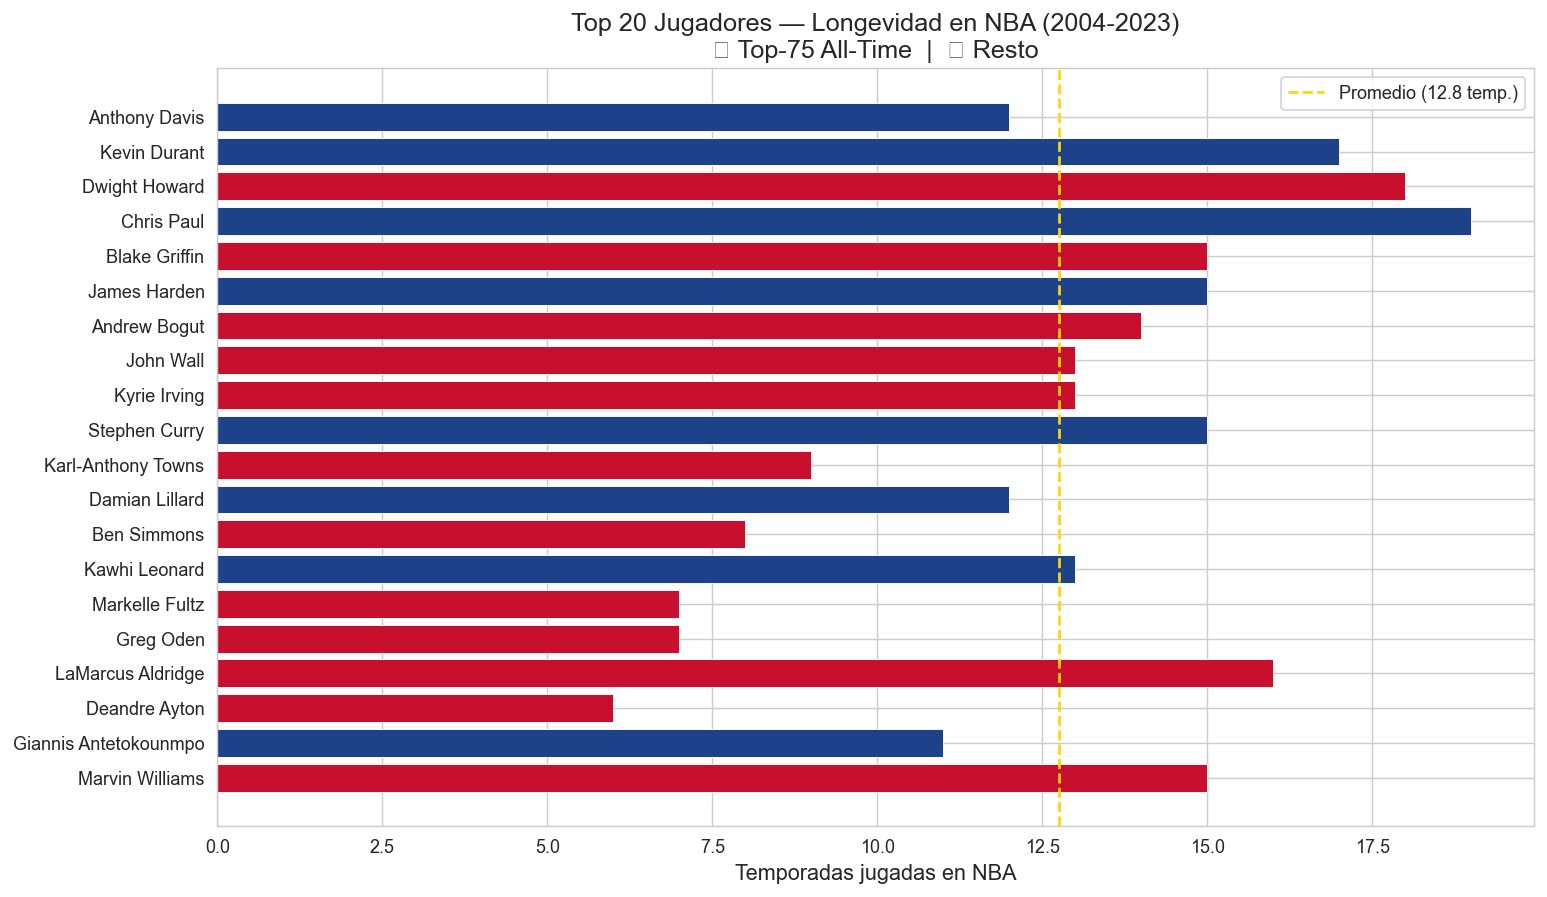

In [53]:
fig, ax = plt.subplots(figsize=(12, 7))

# ✅ Usar is_top75 en lugar de hof_flag
colors = ['#1d428a' if f == 1 else '#c8102e' 
          for f in top20['is_top75']]

# ✅ Usar longevity en lugar de longevity_score
bars = ax.barh(
    top20['player_name'], 
    top20['longevity'],
    color=colors, 
    edgecolor='white', 
    linewidth=0.5
)

ax.set_xlabel('Temporadas jugadas en NBA', fontsize=12)
ax.set_title(
    'Top 20 Jugadores — Longevidad en NBA (2004-2023)\n'
    '🔵 Top-75 All-Time  |  🔴 Resto', 
    fontsize=14
)
ax.invert_yaxis()
ax.axvline(
    top20['longevity'].mean(),       # ✅ corregido
    color='gold', 
    linestyle='--', 
    label=f"Promedio ({top20['longevity'].mean():.1f} temp.)"
)
ax.legend()
plt.tight_layout()
plt.savefig('01_longevidad_top20.png', dpi=150)
plt.show()


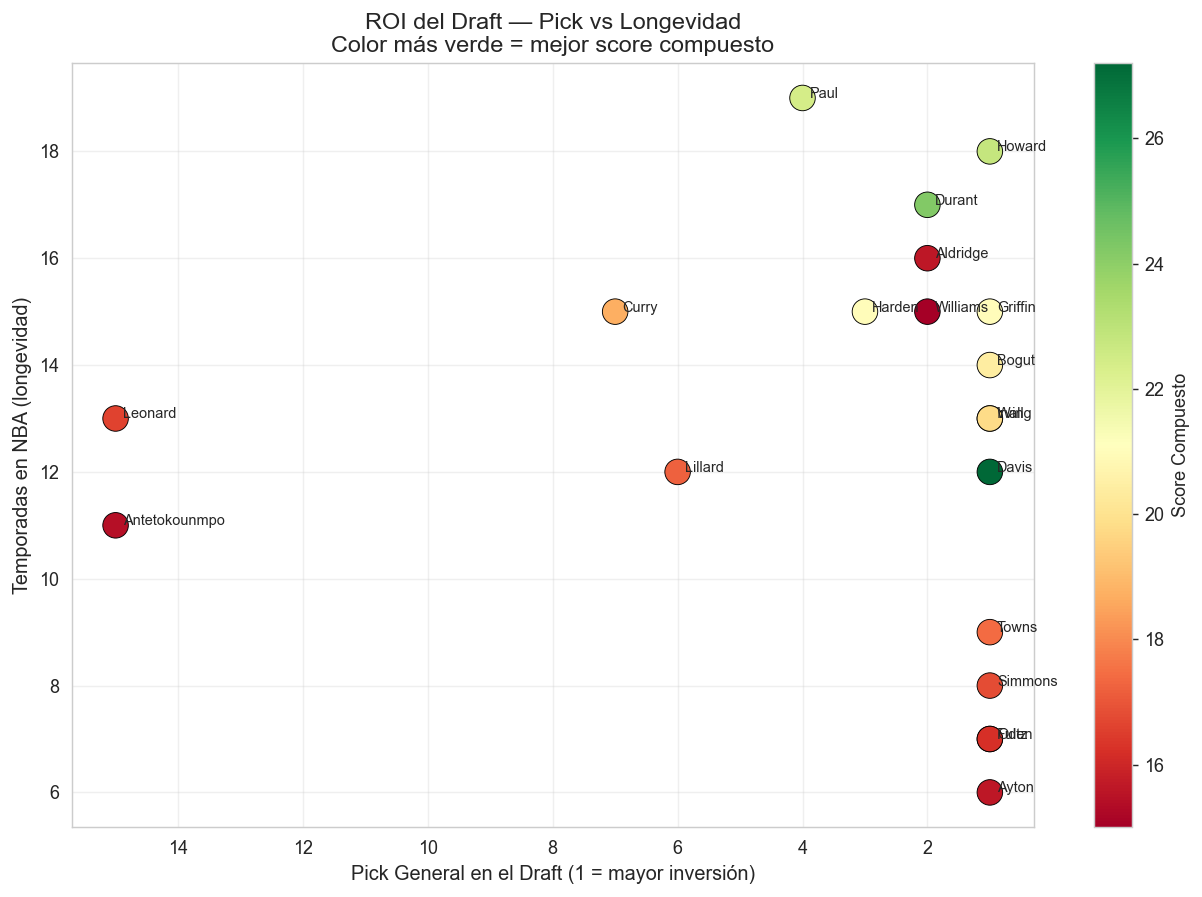

In [55]:
fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(
    top20['overall_pick'],
    top20['longevity'],          # ✅ corregido
    c=top20['composite_score'],
    cmap='RdYlGn',
    s=200, edgecolors='black', linewidths=0.5, zorder=3
)

for _, row in top20.iterrows():
    ax.annotate(
        row['player_name'].split()[-1],       # apellido
        (row['overall_pick'], row['longevity']),  # ✅ corregido
        fontsize=8, ha='left',
        xytext=(4, 0), textcoords='offset points'
    )

plt.colorbar(sc, label='Score Compuesto')
ax.set_xlabel('Pick General en el Draft (1 = mayor inversión)', fontsize=11)
ax.set_ylabel('Temporadas en NBA (longevidad)', fontsize=11)
ax.set_title(
    'ROI del Draft — Pick vs Longevidad\n'
    'Color más verde = mejor score compuesto', 
    fontsize=13
)
ax.invert_xaxis()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('02_roi_scatter.png', dpi=150)
plt.show()


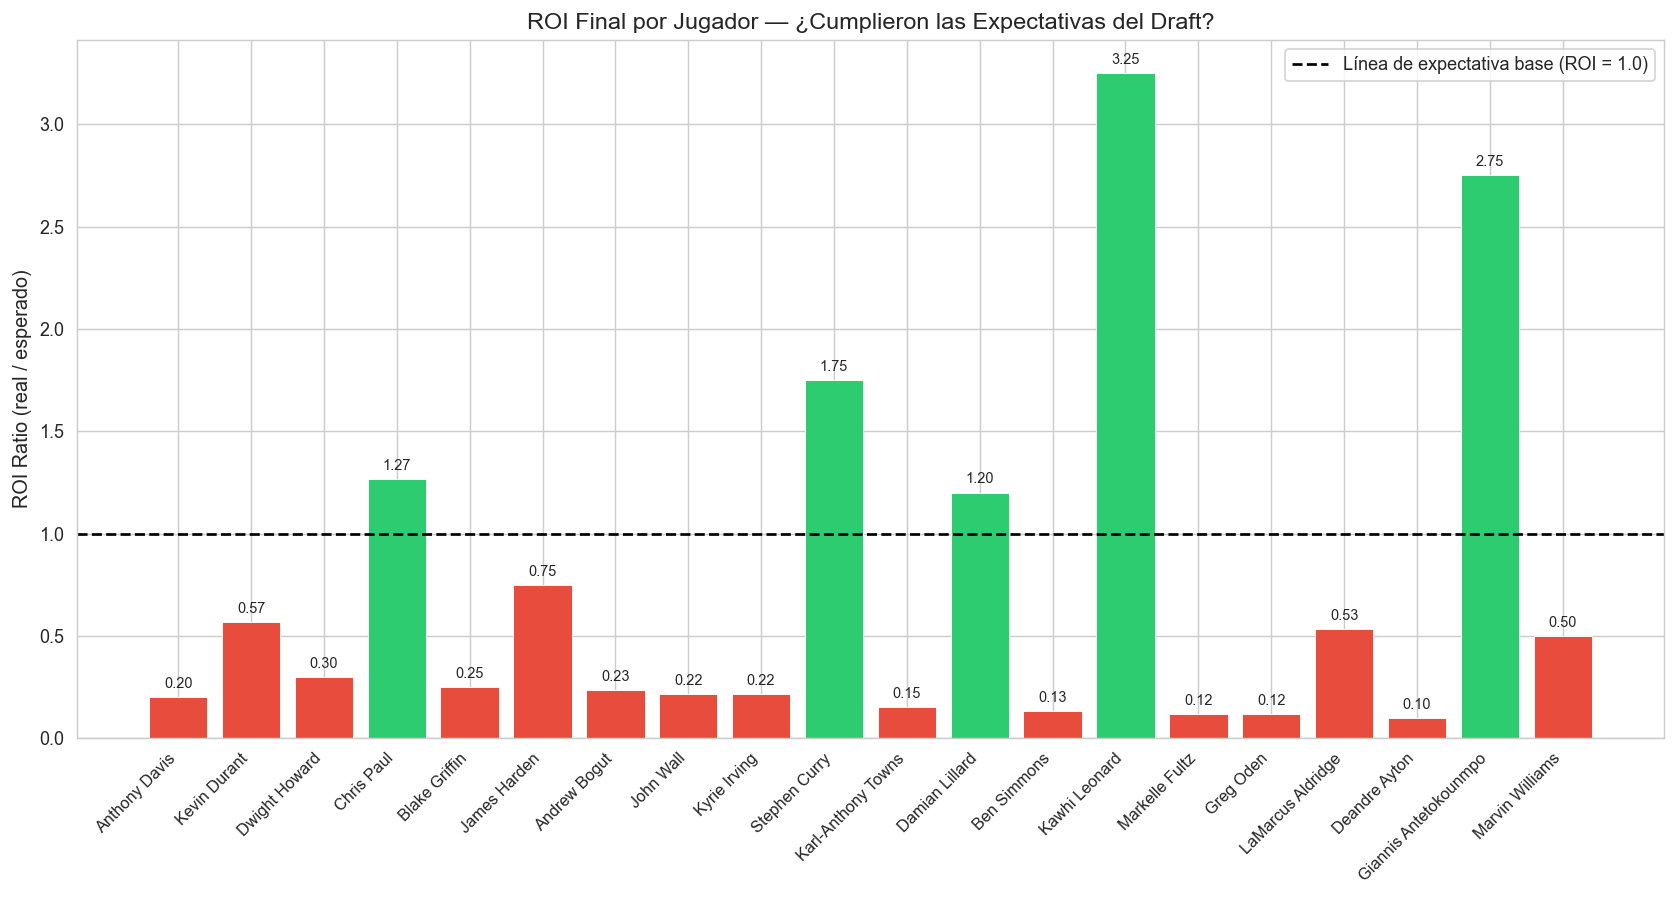

In [58]:
# ✅ Corregido: longevity en lugar de longevity_score
top20['expected_seasons'] = 60 / top20['overall_pick']
top20['roi_ratio'] = top20['longevity'] / top20['expected_seasons']  # ✅
top20['roi_label'] = top20['roi_ratio'].apply(
    lambda x: '🟢 Superó expectativas' if x >= 1 
    else '🔴 Por debajo'
)

fig, ax = plt.subplots(figsize=(13, 7))

colors_roi = ['#2ecc71' if x >= 1 else '#e74c3c' 
              for x in top20['roi_ratio']]

bars = ax.bar(
    top20['player_name'], 
    top20['roi_ratio'],
    color=colors_roi, 
    edgecolor='white', 
    linewidth=0.5
)

# Etiquetas de valor sobre cada barra
for bar, val in zip(bars, top20['roi_ratio']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f'{val:.2f}',
        ha='center', va='bottom', fontsize=8
    )

ax.axhline(1, color='black', linestyle='--', linewidth=1.5,
           label='Línea de expectativa base (ROI = 1.0)')
ax.set_ylabel('ROI Ratio (real / esperado)', fontsize=11)
ax.set_title(
    'ROI Final por Jugador — ¿Cumplieron las Expectativas del Draft?',
    fontsize=13
)
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('04_roi_final.png', dpi=150)
plt.show()


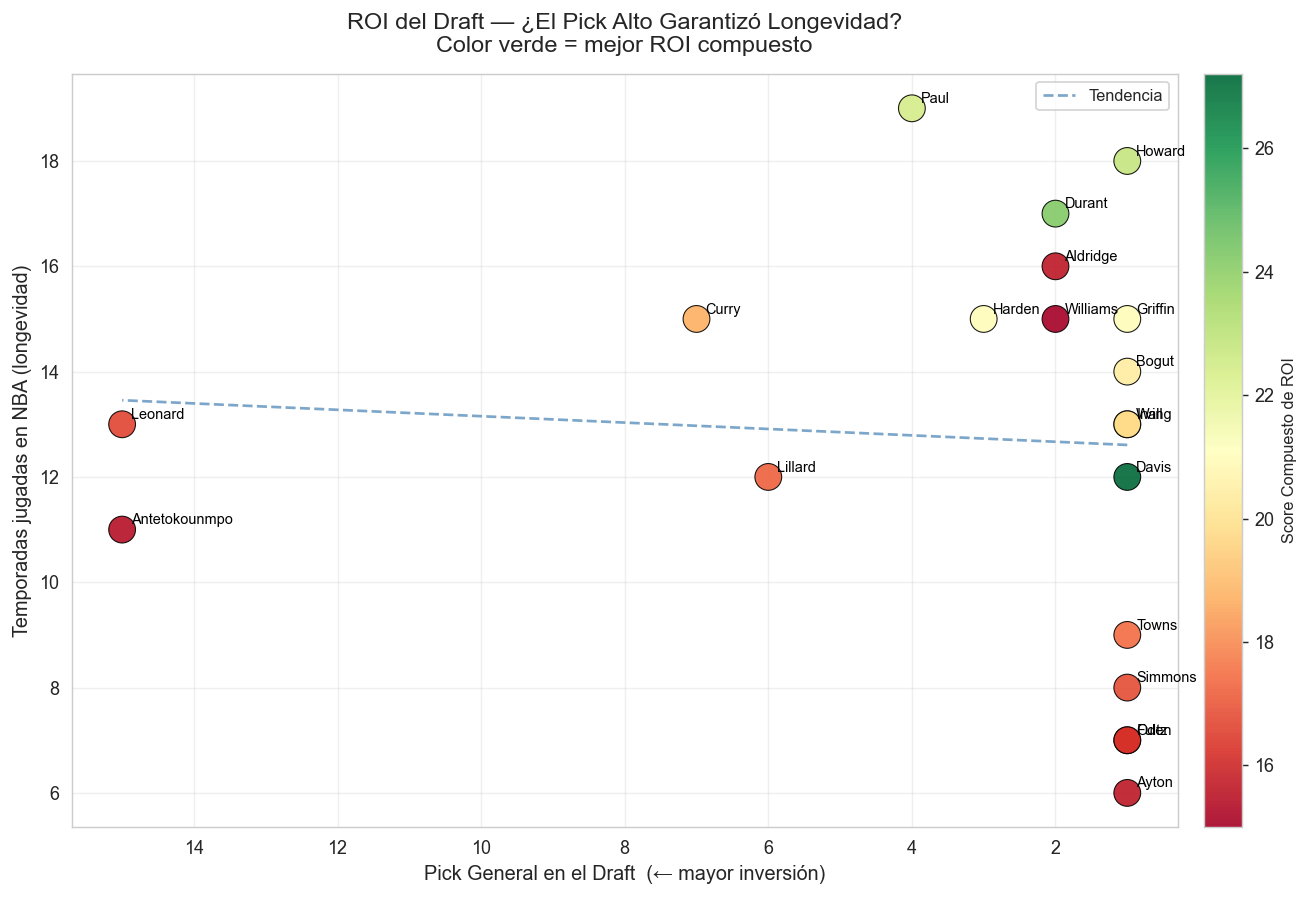

✅ Gráfico 2 guardado


In [ ]:
# CELDA 6 — Visualización 2: Scatter ROI (Pick vs Longevidad)
fig, ax = plt.subplots(figsize=(11, 7))

# Scatter coloreado por composite_score
sc = ax.scatter(
    top20['overall_pick'],
    top20['longevity'],
    c        = top20['composite_score'],
    cmap     = 'RdYlGn',
    s        = 220,
    edgecolors = 'black',
    linewidths = 0.6,
    zorder   = 3,
    alpha    = 0.90
)

# Anotaciones con apellido
for _, row in top20.iterrows():
    nombre = row['player_name'].split()[-1]
    ax.annotate(
        nombre,
        xy       = (row['overall_pick'], row['longevity']),
        xytext   = (5, 3),
        textcoords = 'offset points',
        fontsize = 8,
        color    = 'black'
    )

# Línea de tendencia
z   = np.polyfit(top20['overall_pick'], top20['longevity'], 1)
p   = np.poly1d(z)
xp  = np.linspace(top20['overall_pick'].min(),
                  top20['overall_pick'].max(), 100)
ax.plot(xp, p(xp), '--', color='steelblue',
        linewidth=1.5, alpha=0.7, label='Tendencia')

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('Score Compuesto de ROI', fontsize=9)

ax.set_xlabel('Pick General en el Draft  (← mayor inversión)', fontsize=11)
ax.set_ylabel('Temporadas jugadas en NBA (longevidad)', fontsize=11)
ax.set_title('ROI del Draft — ¿El Pick Alto Garantizó Longevidad?\n'
             'Color verde = mejor ROI compuesto', fontsize=13, pad=12)
ax.invert_xaxis()  # pick #1 a la derecha
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('02_scatter_roi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 2 guardado")


NameError: name 'mpatches' is not defined

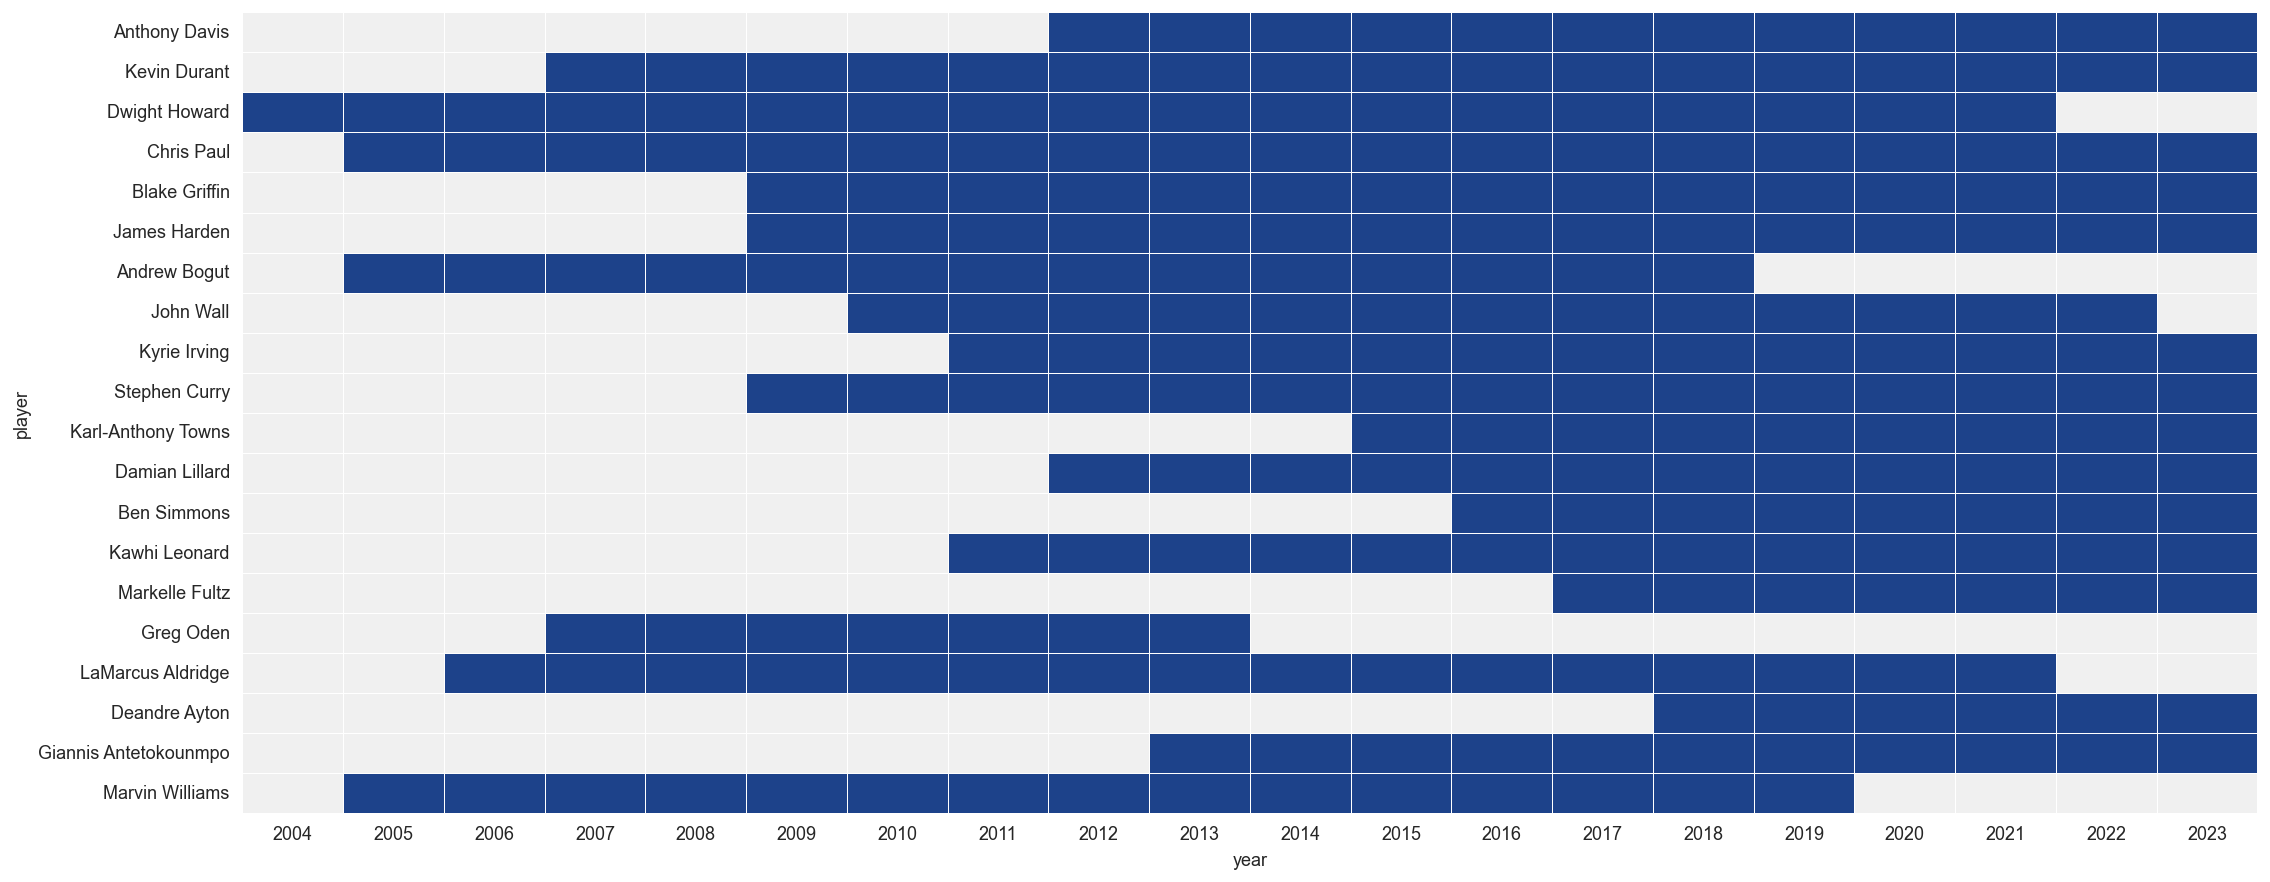

In [60]:
# Visualización 3: Heatmap Timeline de Actividad
# Construir tabla de actividad año a año
timeline_rows = []

for _, row in top20.iterrows():
    start = int(row['from_year']) if pd.notna(row['from_year']) else int(row['season'])
    end   = int(row['to_year'])   if pd.notna(row['to_year'])   else int(start + row['longevity'])
    end   = min(end, 2023)

    for yr in range(start, end + 1):
        if 2004 <= yr <= 2023:
            timeline_rows.append({
                'player'     : row['player_name'],
                'year'       : yr,
                'pick'       : row['overall_pick'],
                'is_top75'   : row['is_top75']
            })

df_timeline = pd.DataFrame(timeline_rows)

# Pivot para heatmap
pivot = df_timeline.pivot_table(
    index   = 'player',
    columns = 'year',
    values  = 'pick',
    aggfunc = 'count',
    fill_value = 0
)

# Binarizar (1 = activo, 0 = no activo)
pivot_bin = (pivot > 0).astype(int)

# Ordenar por pick del draft (top20 ya está ordenado por score)
order = [p for p in top20['player_name'].tolist() if p in pivot_bin.index]
pivot_bin = pivot_bin.reindex(order)

fig, ax = plt.subplots(figsize=(20, 8))

sns.heatmap(
    pivot_bin,
    cmap        = ['#f0f0f0', '#1d428a'],
    linewidths  = 0.4,
    linecolor   = 'white',
    ax          = ax,
    cbar        = False,
    annot       = False
)

# Leyenda manual
patch_act  = mpatches.Patch(color='#1d428a', label='Activo en NBA')
patch_inac = mpatches.Patch(color='#f0f0f0', label='Inactivo / Retirado')
ax.legend(handles=[patch_act, patch_inac],
          loc='upper right', fontsize=9, bbox_to_anchor=(1.01, 1.12))

ax.set_title('Línea de Tiempo de Actividad — TOP 20 Jugadores (2004-2023)\n'
             'Ordenado por Score de ROI (mayor arriba)', fontsize=13, pad=12)
ax.set_xlabel('Temporada', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('03_timeline_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 3 guardado")


NameError: name 'mpatches' is not defined

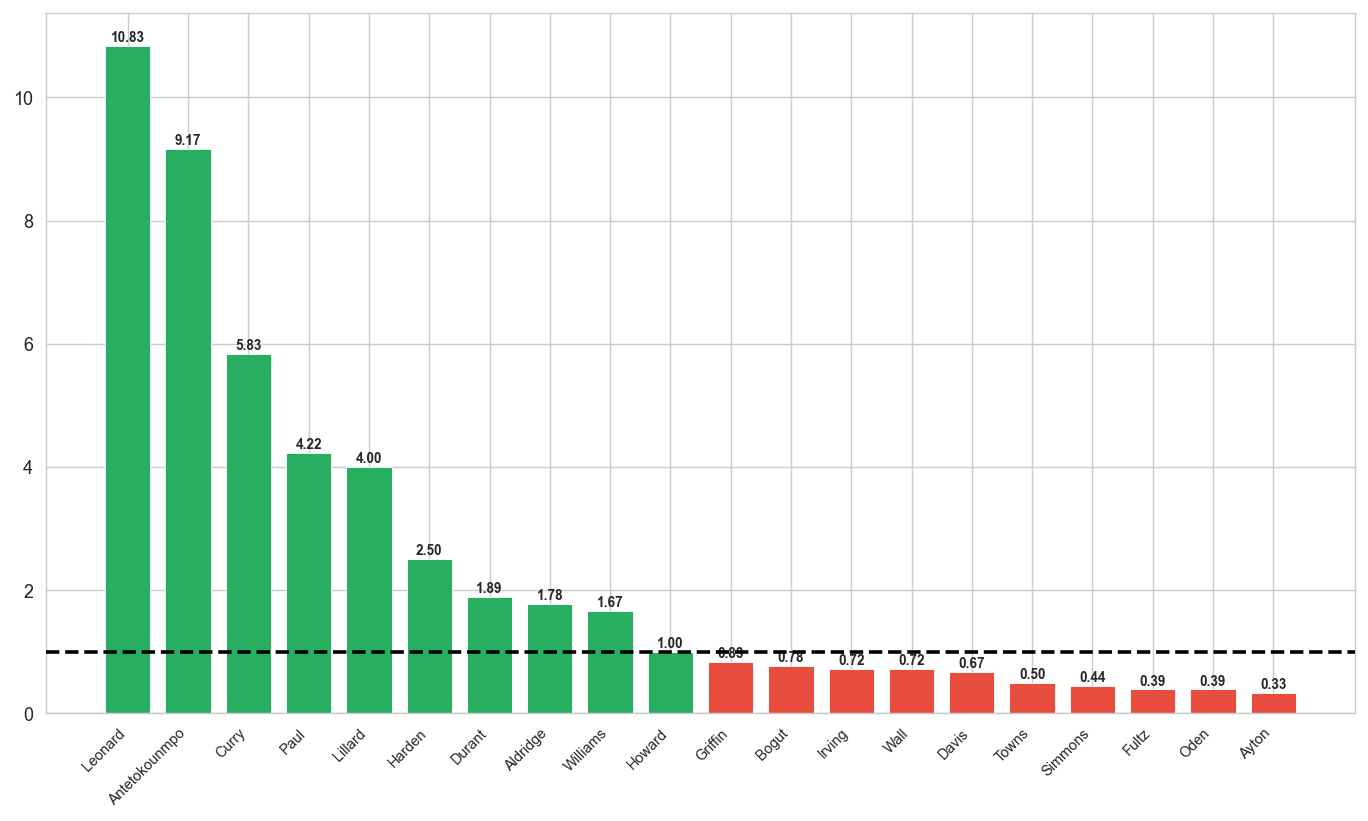

In [ ]:

# Visualización 4: Ratio ROI — ¿Superaron Expectativas?
MAX_EXP = 18  # máximo de temporadas "esperadas" para pick #1

top20 = top20.copy()
top20['expected_seasons'] = MAX_EXP * (1.0 / top20['overall_pick']) / (1.0 / top20['overall_pick'].min())
top20['roi_ratio']        = top20['longevity'] / top20['expected_seasons'].replace(0, np.nan)

# Categoría
top20['roi_cat'] = top20['roi_ratio'].apply(
    lambda x: 'Superó expectativas' if x >= 1.0 else 'Por debajo'
)

# Ordenar por ROI ratio
top20_roi = top20.sort_values('roi_ratio', ascending=False)

fig, ax = plt.subplots(figsize=(13, 7))

colors_roi = ['#27ae60' if c == 'Superó expectativas' else '#e74c3c'
              for c in top20_roi['roi_cat']]

bars = ax.bar(
    range(len(top20_roi)),
    top20_roi['roi_ratio'],
    color      = colors_roi,
    edgecolor  = 'white',
    linewidth  = 0.5,
    width      = 0.75
)

# Línea de expectativa base
ax.axhline(1.0, color='black', linestyle='--', linewidth=2.0,
           label='Expectativa base (ROI = 1.0)', zorder=5)

# Etiquetas en barras
for bar, val in zip(bars, top20_roi['roi_ratio']):
    ypos = bar.get_height() + 0.02
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:.2f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

# Eje x con nombres
ax.set_xticks(range(len(top20_roi)))
ax.set_xticklabels(
    [n.split()[-1] for n in top20_roi['player_name']],
    rotation=45, ha='right', fontsize=8
)

patch_sup = mpatches.Patch(color='#27ae60', label='Superó expectativas (ROI ≥ 1)')
patch_inf = mpatches.Patch(color='#e74c3c', label='Por debajo (ROI < 1)')
ax.legend(handles=[patch_sup, patch_inf,
          mpatches.Patch(color='black', label='Línea base = 1.0')],
          fontsize=9, loc='upper right')

ax.set_ylabel('ROI Ratio  (temporadas reales / temporadas esperadas)', fontsize=10)
ax.set_title('ROI Final — ¿Cumplieron las Expectativas del Draft?\n'
             'Jugadores Drafteados 2004-2018 | Top 20 por Score Compuesto',
             fontsize=13, pad=12)
ax.set_ylim(0, top20_roi['roi_ratio'].max() + 0.5)
plt.tight_layout()
plt.savefig('04_roi_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 4 guardado")


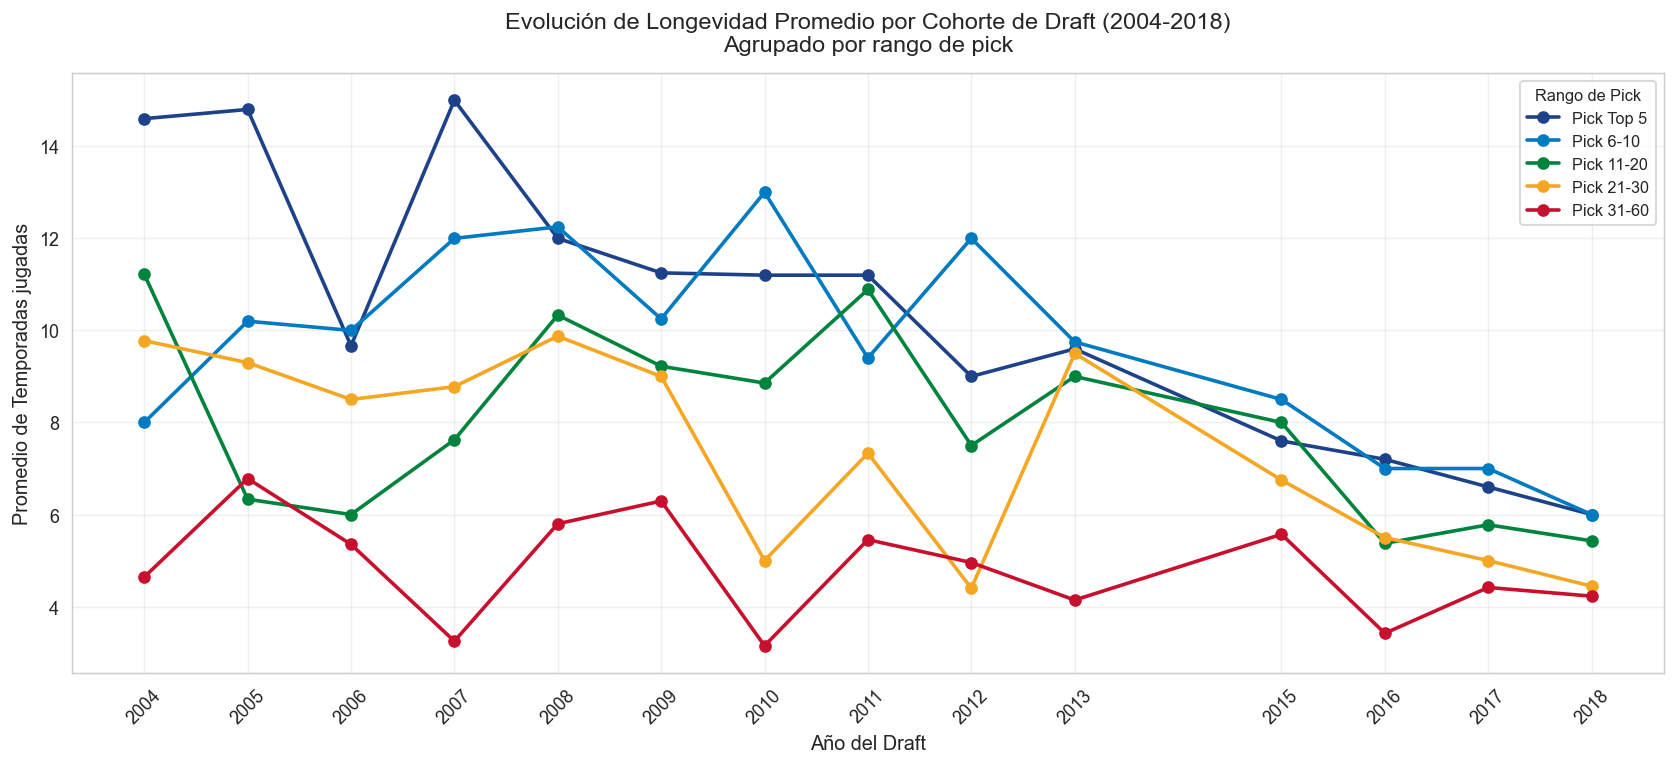

✅ Gráfico 5 guardado


In [63]:
# Visualización 5: Evolución por Cohorte de Draft
# Agrupar por año de draft y calcular longevidad promedio
cohort_stats = (
    draft_filtered
    .merge(common_clean, left_on='person_id', right_on='player_id', how='inner')
    .assign(
        longevity    = lambda d: d['season_exp_calculated'].fillna(0),
        pick_tier    = lambda d: pd.cut(d['overall_pick'],
                                        bins  = [0, 5, 10, 20, 30, 60],
                                        labels= ['Top 5','6-10','11-20','21-30','31-60'])
    )
    .groupby(['season', 'pick_tier'], observed=True)['longevity']
    .mean()
    .reset_index()
    .rename(columns={'longevity': 'avg_longevity', 'season': 'draft_year'})
)

fig, ax = plt.subplots(figsize=(13, 6))

palette = {
    'Top 5'  : '#1d428a',
    '6-10'   : '#007ac1',
    '11-20'  : '#00843d',
    '21-30'  : '#f5a623',
    '31-60'  : '#c8102e'
}

for tier, grp in cohort_stats.groupby('pick_tier', observed=True):
    ax.plot(
        grp['draft_year'],
        grp['avg_longevity'],
        marker    = 'o',
        linewidth = 2.0,
        markersize= 6,
        label     = f'Pick {tier}',
        color     = palette.get(str(tier), 'gray')
    )

ax.set_xlabel('Año del Draft', fontsize=11)
ax.set_ylabel('Promedio de Temporadas jugadas', fontsize=11)
ax.set_title('Evolución de Longevidad Promedio por Cohorte de Draft (2004-2018)\n'
             'Agrupado por rango de pick', fontsize=13, pad=12)
ax.legend(title='Rango de Pick', fontsize=9, title_fontsize=9)
ax.set_xticks(sorted(cohort_stats['draft_year'].unique()))
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('05_evolucion_cohorte.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 5 guardado")


In [ ]:
#Tabla Resumen Final
print("\n" + "="*65)
print("         RESUMEN EDA — ROI TOP 20 JUGADORES NBA 2004-2023")
print("="*65)

resumen = top20[['player_name', 'season', 'overall_pick',
                  'longevity', 'is_top75', 'roi_ratio', 'roi_cat']].copy()

resumen.columns = ['Jugador', 'Draft', 'Pick', 'Temporadas',
                    'Top75', 'ROI Ratio', 'Resultado']

resumen['Top75']     = resumen['Top75'].map({1: '⭐ Sí', 0: 'No'})
resumen['ROI Ratio'] = resumen['ROI Ratio'].round(2)
resumen['Resultado'] = resumen['Resultado'].map({
    'Superó expectativas' : '✅ Superó',
    'Por debajo'          : '❌ Decepcionó'
})

print(resumen.to_string(index=True))

print(f"\n📊 Jugadores que superaron expectativas : "
      f"{(resumen['Resultado'] == '✅ Superó').sum()} / 20")
print(f"⭐ Jugadores Top-75 All-Time en el top20 : "
      f"{(resumen['Top75'] == '⭐ Sí').sum()} / 20")
print(f"📈 ROI Ratio promedio                    : "
      f"{top20['roi_ratio'].mean():.2f}")
print(f"🏆 Mayor ROI                             : "
      f"{top20.loc[top20['roi_ratio'].idxmax(), 'player_name']} "
      f"({top20['roi_ratio'].max():.2f})")
print(f"📉 Menor ROI                             : "
      f"{top20.loc[top20['roi_ratio'].idxmin(), 'player_name']} "
      f"({top20['roi_ratio'].min():.2f})")



         RESUMEN EDA — ROI TOP 20 JUGADORES NBA 2004-2023
                  Jugador  Draft  Pick  Temporadas Top75  ROI Ratio     Resultado
1           Anthony Davis   2012     1        12.0  ⭐ Sí       0.67  ❌ Decepcionó
2            Kevin Durant   2007     2        17.0  ⭐ Sí       1.89      ✅ Superó
3           Dwight Howard   2004     1        18.0    No       1.00      ✅ Superó
4              Chris Paul   2005     4        19.0  ⭐ Sí       4.22      ✅ Superó
5           Blake Griffin   2009     1        15.0    No       0.83  ❌ Decepcionó
6            James Harden   2009     3        15.0  ⭐ Sí       2.50      ✅ Superó
7            Andrew Bogut   2005     1        14.0    No       0.78  ❌ Decepcionó
8               John Wall   2010     1        13.0    No       0.72  ❌ Decepcionó
9            Kyrie Irving   2011     1        13.0    No       0.72  ❌ Decepcionó
10          Stephen Curry   2009     7        15.0  ⭐ Sí       5.83      ✅ Superó
11     Karl-Anthony Towns   2015     1 